In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
class PromptChainState(TypedDict):
    topic: str
    outline: str
    content: str
    evaluation: str

In [3]:
model = ChatOpenAI()

In [4]:
def make_outline(state: PromptChainState) -> PromptChainState:
    # code to generate outline from topic
    prompt = f"Provide the outline for topic '{state['topic']}'"
    state['outline'] = model.invoke(prompt).content
    return state

In [5]:
def write_content(state: PromptChainState) -> PromptChainState:
    # code to generate content from outline
    prompt = f"Write content for the following outline: '{state['outline']}'"
    state['content'] = model.invoke(prompt).content
    return state

In [6]:
def evaluate_content(state: PromptChainState) -> PromptChainState:
    # code to evaluate the content
    prompt = f"Evaluate the following content: '{state['content']}' and provide feedback. The format should be 'score': <1-10> 'Evaluation: <your evaluation>'"
    state['evaluation'] = model.invoke(prompt).content
    return state

In [7]:
graph = StateGraph(PromptChainState)

In [8]:
graph.add_node('makeOutline', make_outline)
graph.add_node('writeContent', write_content)
graph.add_node('evaluate', evaluate_content)

In [9]:
graph.add_edge(START, 'makeOutline')
graph.add_edge('makeOutline', 'writeContent')
graph.add_edge('writeContent', 'evaluate')
graph.add_edge('evaluate', END)

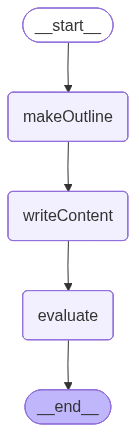

In [10]:
graph.compile()

In [11]:
workflow = graph.compile()
initial_state = {"topic": "The impact of AI on society in 3 lines"}
final_state = workflow.invoke(initial_state)
print(final_state['content'])
print(final_state['evaluation'])

I. Introduction to AI technology and its rapid advancement

Artificial Intelligence (AI) is a revolutionary technology that has been rapidly advancing in recent years. AI involves the development of computer systems that can perform tasks that typically require human intelligence, such as decision-making, problem-solving, and pattern recognition. With advancements in machine learning, neural networks, and natural language processing, AI has become increasingly integrated into various aspects of society, from business operations to healthcare to entertainment.

II. Positive impacts of AI on society

One of the major positive impacts of AI on society is increased productivity and efficiency. AI-powered systems are capable of handling large amounts of data at a much faster rate than humans, leading to faster and more accurate decision-making. This has the potential to streamline processes and improve overall productivity in industries such as manufacturing, finance, and healthcare. Additi